# Electricity Consumption Prediction
**Domain:** Environment & Energy  
**Problem Type:** Regression  
**Dataset:** Household Electricity Bill Dataset — Indian Cities

---
## Part 1 - Problem Definition

**What is the problem?**  
Every household uses electricity for fans, refrigerators, air conditioners, televisions and other appliances. The electricity bill at the end of the month depends on how many appliances are used, for how many hours, and what the electricity tariff rate is. We want to build a Machine Learning model that can **predict the monthly electricity bill** of a household based on these features.

**Why is this problem important?**  
Electricity bills are a major household expense in India. If people can predict their electricity bill in advance, they can:
- Reduce unnecessary appliance usage to save money
- Plan their monthly budget better
- Identify which appliances consume the most electricity

**Who will benefit?**  
- **Households** - to manage and reduce electricity costs
- **Electricity companies** - to forecast demand and plan supply
- **Government** - for energy conservation planning

**Why is Machine Learning suitable?**  
The electricity bill depends on many factors together - number of appliances, usage hours, city, month, and tariff rate. These interact with each other in complex ways. Machine Learning can learn these patterns from thousands of past records and make accurate predictions.

---
## Part 2 - Dataset Description

| Property | Details |
|---|---|
| Dataset Name | Household Electricity Bill Dataset |
| Source | Kaggle |
| File | electricity_bill_dataset.csv |
| Number of Rows | 45,345 |
| Number of Columns | 12 |
| Target Variable | ElectricityBill (in Rupees) |
| Coverage | Multiple Indian cities |

**Columns:**
- Fan - number of fans in the house
- Refrigerator - number of refrigerators
- AirConditioner - number of air conditioners
- Television - number of televisions
- Monitor - number of computer monitors
- MotorPump - number of motor pumps
- Month - month of the year (1 to 12)
- City - city where the house is located
- Company - electricity provider company
- MonthlyHours - total hours of electricity usage in a month
- TariffRate - electricity rate per unit (in Rs/kWh)
- **ElectricityBill** - monthly electricity bill in Rupees (Target Variable)

**Dataset Limitations:**
- Does not include house size or number of rooms
- No information about house insulation or building type
- Does not capture exact usage hours per appliance separately

---
## Step 1 - Import Libraries

In [1]:
# Importing all the libraries we need

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2 - Load the Dataset

In [2]:
# Load the CSV file
df = pd.read_csv('../Dataset/Electricity_Consumption/electricity_bill_dataset.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print()
df.head(10)

Dataset loaded successfully!
Shape: (45345, 12)



,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,Hyderabad,Tata Power Company Ltd.,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,Vadodara,NHPC,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,Shimla,Jyoti Structure,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,Mumbai,Power Grid Corp,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,Mumbai,Ratnagiri Gas and Power Pvt. Ltd. (RGPPL),457,9.2,4204.4
5,13,22.0,0.0,18.0,1.0,0,6,Ratnagiri,Adani Power Ltd.,471,7.4,3485.4
6,23,22.0,3.0,20.0,12.0,0,5,New Delhi,Kalpataru Power,755,8.5,6417.5
7,22,23.0,0.0,21.0,1.0,0,12,New Delhi,Adani Power Ltd.,492,8.5,4182.0
8,8,20.0,2.0,8.0,1.0,0,8,New Delhi,Orient Green,546,8.5,4641.0
9,10,23.0,0.0,18.0,7.0,0,1,Dahej,Sterlite Power Transmission Ltd,578,7.6,4392.8


---
## Step 3 - Data Understanding

In [3]:
# Check data types and count of non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45345 entries, 0 to 45344
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fan              45345 non-null  int64  
 1   Refrigerator     45345 non-null  float64
 2   AirConditioner   45345 non-null  float64
 3   Television       45345 non-null  float64
 4   Monitor          45345 non-null  float64
 5   MotorPump        45345 non-null  int64  
 6   Month            45345 non-null  int64  
 7   City             45345 non-null  str    
 8   Company          45345 non-null  str    
 9   MonthlyHours     45345 non-null  int64  
 10  TariffRate       45345 non-null  float64
 11  ElectricityBill  45345 non-null  float64
dtypes: float64(6), int64(4), str(2)
memory usage: 4.2 MB


In [4]:
# Basic statistics
df.describe()

,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,MonthlyHours,TariffRate,ElectricityBill
count,45345.000000,45345.000000,45345.000000,45345.000000,45345.000000,45345.0,45345.000000,45345.000000,45345.000000,45345.000000
mean,13.990694,21.705458,1.503959,12.502635,2.865057,0.0,6.488058,515.083207,8.369648,4311.771307
std,5.470816,1.672575,1.115482,5.756007,3.894933,0.0,3.443252,122.618017,0.576992,1073.886406
min,5.000000,17.000000,0.000000,3.000000,1.000000,0.0,1.000000,95.000000,7.400000,807.500000
25%,9.000000,22.000000,1.000000,7.000000,1.000000,0.0,3.000000,429.000000,7.900000,3556.800000
50%,14.000000,22.000000,2.000000,13.000000,1.000000,0.0,6.000000,515.000000,8.400000,4299.400000
75%,19.000000,23.000000,2.000000,17.000000,1.000000,0.0,9.000000,601.000000,8.900000,5038.800000
max,23.000000,23.000000,3.000000,22.000000,12.000000,0.0,12.000000,926.000000,9.300000,8286.300000


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Fan                0
Refrigerator       0
AirConditioner     0
Television         0
Monitor            0
MotorPump          0
Month              0
City               0
Company            0
MonthlyHours       0
TariffRate         0
ElectricityBill    0
dtype: int64


In [6]:
# Check unique values in categorical columns
print("Cities:", df['City'].unique())
print()
print("Total cities:", df['City'].nunique())
print()
print("Electricity Companies:", df['Company'].unique())
print()
print("Months covered:", sorted(df['Month'].unique()))

Cities: <StringArray>
[  'Hyderabad',    'Vadodara',      'Shimla',      'Mumbai',   'Ratnagiri',
   'New Delhi',       'Dahej',   'Ahmedabad',       'Noida',      'Nagpur',
     'Chennai',   'Faridabad',     'Kolkata',        'Pune',     'Gurgaon',
 'Navi Mumbai']
Length: 16, dtype: str

Total cities: 16

Electricity Companies: <StringArray>
[                                           'Tata Power Company Ltd.',
                                                               'NHPC',
                                                    'Jyoti Structure',
                                                    'Power Grid Corp',
                          'Ratnagiri Gas and Power Pvt. Ltd. (RGPPL)',
                                                   'Adani Power Ltd.',
                                                    'Kalpataru Power',
                                                       'Orient Green',
                                    'Sterlite Power Transmission Ltd',
                

In [7]:
# Check the target variable range
print("Electricity Bill Statistics (in Rupees):")
print("  Minimum  :", round(df['ElectricityBill'].min(), 2))
print("  Maximum  :", round(df['ElectricityBill'].max(), 2))
print("  Average  :", round(df['ElectricityBill'].mean(), 2))
print("  Median   :", round(df['ElectricityBill'].median(), 2))

Electricity Bill Statistics (in Rupees):
  Minimum  : 807.5
  Maximum  : 8286.3
  Average  : 4311.77
  Median   : 4299.4


---
## Step 4 - Data Preprocessing

In [8]:
# Step 4.1 - Remove duplicate rows
print("Rows before:", len(df))
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows before: 45345
Rows after removing duplicates: 45345


In [9]:
# Step 4.2 - Encode City column
# ML models work with numbers only, not text
# LabelEncoder converts city names to numbers

le_city = LabelEncoder()
df['City'] = le_city.fit_transform(df['City'])

print("City encoding done!")
print("City mapping:")
for name, code in zip(le_city.classes_, le_city.transform(le_city.classes_)):
    print(" ", name, "=", code)

City encoding done!
City mapping:
  Ahmedabad = 0
  Chennai = 1
  Dahej = 2
  Faridabad = 3
  Gurgaon = 4
  Hyderabad = 5
  Kolkata = 6
  Mumbai = 7
  Nagpur = 8
  Navi Mumbai = 9
  New Delhi = 10
  Noida = 11
  Pune = 12
  Ratnagiri = 13
  Shimla = 14
  Vadodara = 15


In [10]:
# Step 4.3 - Encode Company column
le_company = LabelEncoder()
df['Company'] = le_company.fit_transform(df['Company'])

print("Company encoding done!")
print("Company mapping:")
for name, code in zip(le_company.classes_, le_company.transform(le_company.classes_)):
    print(" ", name, "=", code)

Company encoding done!
Company mapping:
  Adani Power Ltd. = 0
  Bonfiglioli Transmission Pvt. Ltd. = 1
  CESC = 2
  GE T&D India Limited = 3
  Guj Ind Power = 4
  Indowind Energy = 5
  JSW Energy Ltd. = 6
  Jaiprakash Power = 7
  Jyoti Structure = 8
  KEC International = 9
  Kalpataru Power = 10
  L&T Transmission & Distribution = 11
  Maha Transco – Maharashtra State Electricity Transmission Co, Ltd. = 12
  NHPC = 13
  NLC India = 14
  NTPC Pvt. Ltd. = 15
  Neueon Towers / Sujana Towers Ltd. = 16
  Optibelt Power Transmission India Private Limited = 17
  Orient Green = 18
  Power Grid Corp = 19
  Ratnagiri Gas and Power Pvt. Ltd. (RGPPL) = 20
  Reliance Energy = 21
  Reliance Power = 22
  Ringfeder Power Transmission India Pvt. Ltd. = 23
  SJVN Ltd. = 24
  Sterlite Power Transmission Ltd = 25
  Sunil Hitech Eng = 26
  Tata Power Company Ltd. = 27
  Torrent Power Ltd. = 28
  Toshiba Transmission & Distribution Systems (India) Pvt. Ltd. = 29
  TransRail Lighting = 30
  Unitech Power Tr

In [11]:
# Check the cleaned dataset
print("Final dataset shape:", df.shape)
print()
print("Missing values after preprocessing:")
print(df.isnull().sum())
print()
df.head(5)

Final dataset shape: (45345, 12)

Missing values after preprocessing:
Fan                0
Refrigerator       0
AirConditioner     0
Television         0
Monitor            0
MotorPump          0
Month              0
City               0
Company            0
MonthlyHours       0
TariffRate         0
ElectricityBill    0
dtype: int64



,Fan,Refrigerator,AirConditioner,Television,Monitor,MotorPump,Month,City,Company,MonthlyHours,TariffRate,ElectricityBill
0,16,23.0,2.0,6.0,1.0,0,10,5,27,384,8.4,3225.6
1,19,22.0,2.0,3.0,1.0,0,5,15,13,488,7.8,3806.4
2,7,20.0,2.0,6.0,7.0,0,7,14,8,416,7.7,3203.2
3,7,22.0,3.0,21.0,1.0,0,6,7,19,475,9.2,4370.0
4,11,23.0,2.0,11.0,1.0,0,2,7,20,457,9.2,4204.4


---
## Step 5 - Exploratory Data Analysis (EDA)

We will create 7 visualizations to understand the data.

In [12]:
# Reload original data for EDA so we can use original city/company names
df_eda = pd.read_csv('../Dataset/Electricity_Consumption/electricity_bill_dataset.csv')
df_eda = df_eda.drop_duplicates()
print("EDA dataframe shape:", df_eda.shape)

EDA dataframe shape: (45345, 12)


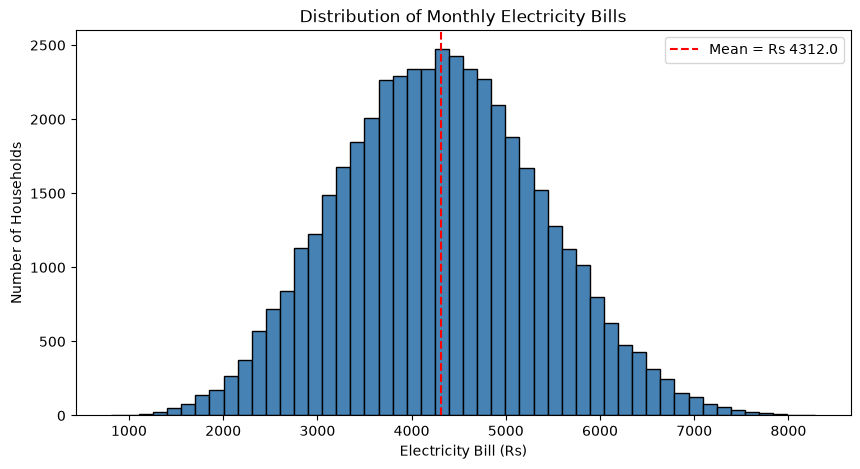

Insight: Most households have bills between Rs 2000 to Rs 6000 per month.
The distribution is roughly spread across the range, not highly skewed.


In [13]:
# Visualization 1 - Histogram of Electricity Bill
# How are electricity bills distributed?

plt.figure(figsize=(10, 5))
plt.hist(df_eda['ElectricityBill'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Monthly Electricity Bills')
plt.xlabel('Electricity Bill (Rs)')
plt.ylabel('Number of Households')
plt.axvline(df_eda['ElectricityBill'].mean(), color='red', linestyle='--',
            label='Mean = Rs ' + str(round(df_eda['ElectricityBill'].mean(), 0)))
plt.legend()
plt.show()

print("Insight: Most households have bills between Rs 2000 to Rs 6000 per month.")
print("The distribution is roughly spread across the range, not highly skewed.")

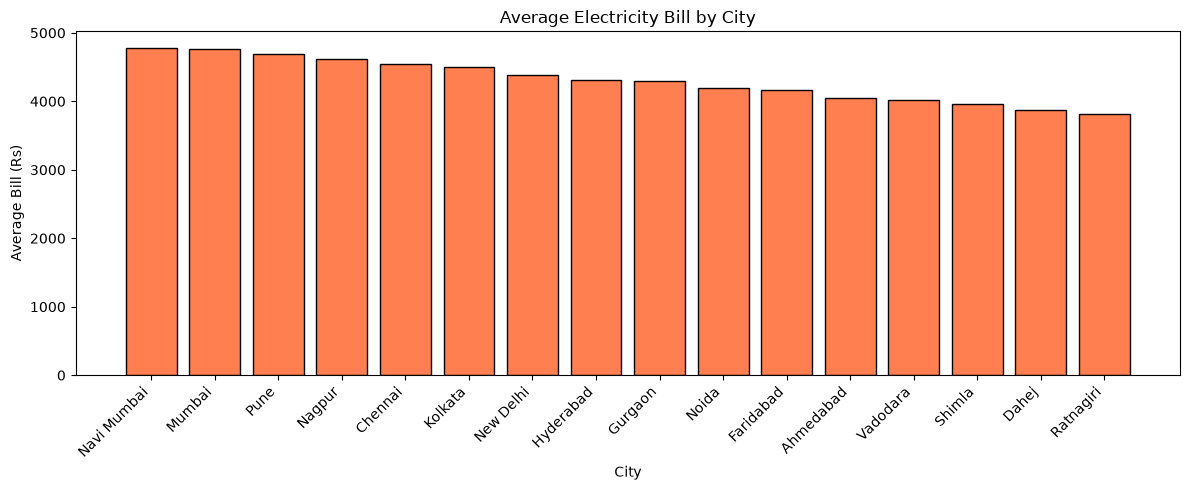

Insight: Cities with hotter climates tend to have higher bills due to heavy AC usage.


In [14]:
# Visualization 2 - Bar chart of Average Bill by City
# Which city has the highest electricity bills?

city_avg = df_eda.groupby('City')['ElectricityBill'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(city_avg.index, city_avg.values, color='coral', edgecolor='black')
plt.title('Average Electricity Bill by City')
plt.xlabel('City')
plt.ylabel('Average Bill (Rs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Insight: Cities with hotter climates tend to have higher bills due to heavy AC usage.")

<Figure size 1400x600 with 0 Axes>

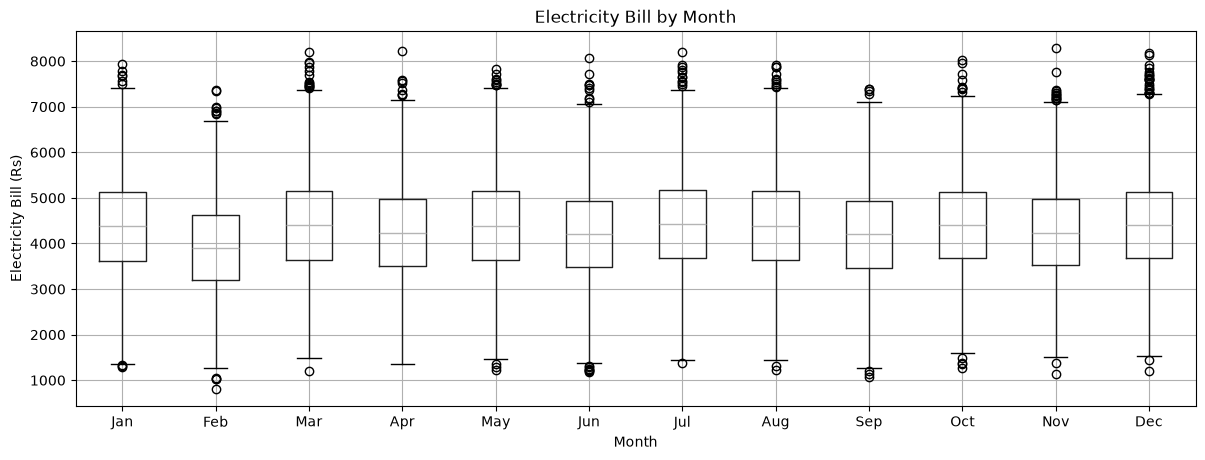

Insight: Bills are higher in summer months (April to June) due to increased AC usage.
Winter months have slightly lower bills.


In [15]:
# Visualization 3 - Box plot of Bill by Month
# Does the electricity bill change across months?

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df_eda['Month_Name'] = df_eda['Month'].map(month_names)
month_order = list(month_names.values())

plt.figure(figsize=(14, 6))
df_eda.boxplot(column='ElectricityBill', by='Month', figsize=(14, 5))
plt.title('Electricity Bill by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Electricity Bill (Rs)')
plt.xticks(ticks=range(1, 13), labels=month_names.values())
plt.show()

print("Insight: Bills are higher in summer months (April to June) due to increased AC usage.")
print("Winter months have slightly lower bills.")

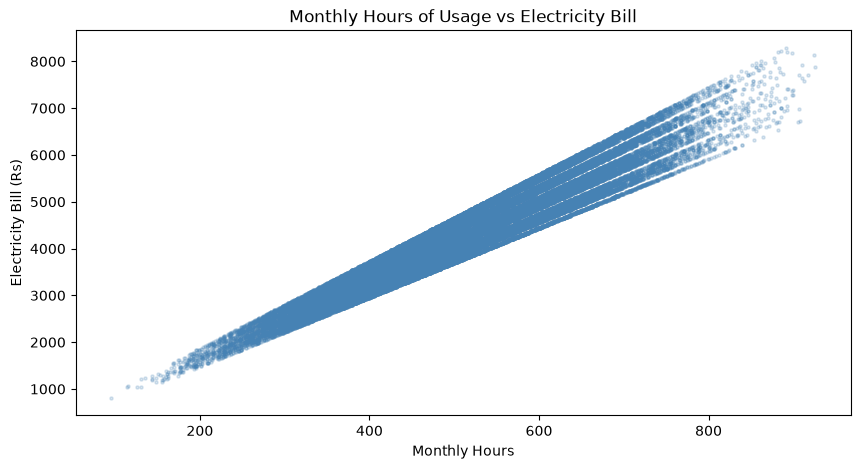

Insight: There is a positive relationship between usage hours and electricity bill.
More hours of usage generally means a higher bill.


In [16]:
# Visualization 4 - Scatter plot of Monthly Hours vs Electricity Bill
# Does more usage hours mean higher bill?

plt.figure(figsize=(10, 5))
plt.scatter(df_eda['MonthlyHours'], df_eda['ElectricityBill'], alpha=0.2, s=5, color='steelblue')
plt.title('Monthly Hours of Usage vs Electricity Bill')
plt.xlabel('Monthly Hours')
plt.ylabel('Electricity Bill (Rs)')
plt.show()

print("Insight: There is a positive relationship between usage hours and electricity bill.")
print("More hours of usage generally means a higher bill.")

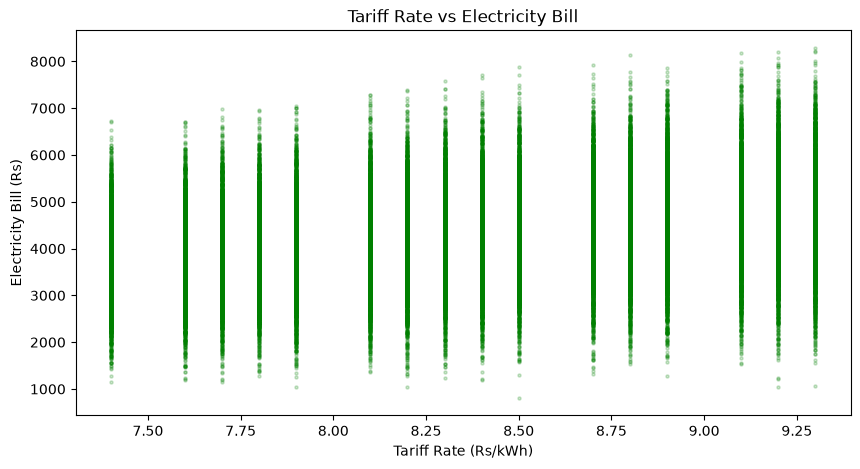

Insight: Higher tariff rate directly increases the electricity bill.
This is an important feature for the model.


In [17]:
# Visualization 5 - Scatter plot of Tariff Rate vs Electricity Bill

plt.figure(figsize=(10, 5))
plt.scatter(df_eda['TariffRate'], df_eda['ElectricityBill'], alpha=0.2, s=5, color='green')
plt.title('Tariff Rate vs Electricity Bill')
plt.xlabel('Tariff Rate (Rs/kWh)')
plt.ylabel('Electricity Bill (Rs)')
plt.show()

print("Insight: Higher tariff rate directly increases the electricity bill.")
print("This is an important feature for the model.")

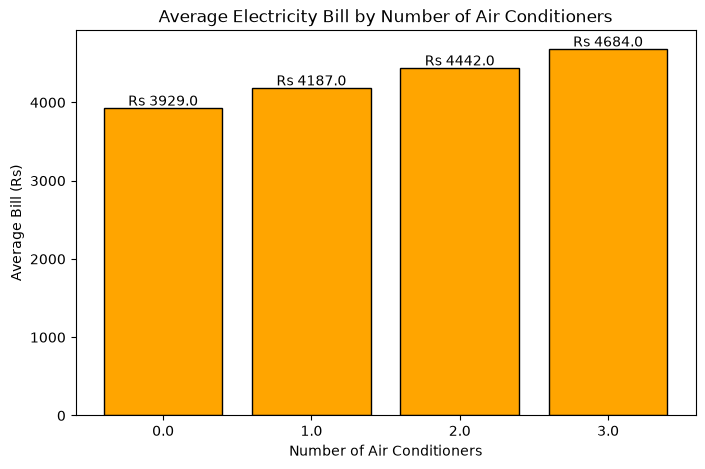

Insight: Households with more ACs have significantly higher electricity bills.
AC is one of the biggest electricity consumers in a household.


In [18]:
# Visualization 6 - Bar chart of Average Bill by Number of ACs
# Does having more ACs increase the bill significantly?

ac_avg = df_eda.groupby('AirConditioner')['ElectricityBill'].mean()

plt.figure(figsize=(8, 5))
plt.bar(ac_avg.index.astype(str), ac_avg.values, color='orange', edgecolor='black')
plt.title('Average Electricity Bill by Number of Air Conditioners')
plt.xlabel('Number of Air Conditioners')
plt.ylabel('Average Bill (Rs)')
for i, v in enumerate(ac_avg.values):
    plt.text(i, v + 30, 'Rs ' + str(round(v, 0)), ha='center', fontsize=10)
plt.show()

print("Insight: Households with more ACs have significantly higher electricity bills.")
print("AC is one of the biggest electricity consumers in a household.")

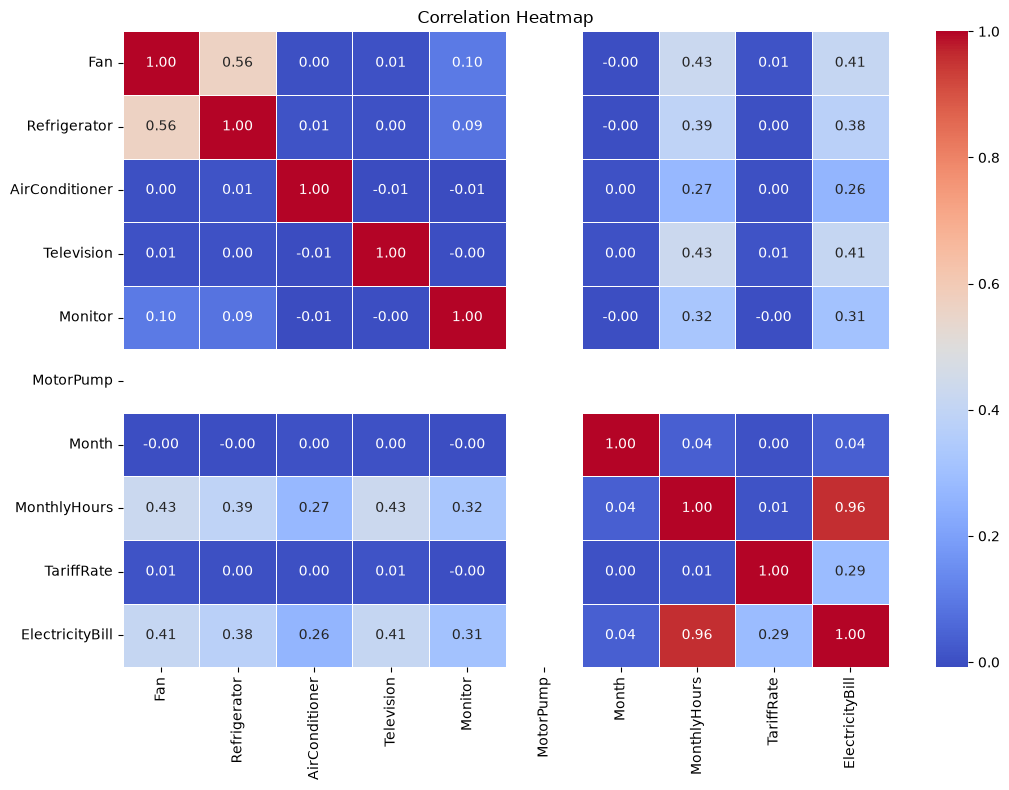

Insight: MonthlyHours and TariffRate have the strongest correlation with ElectricityBill.
AirConditioner also has a noticeable positive correlation with the bill.


In [19]:
# Visualization 7 - Correlation Heatmap
# Which features are most related to the electricity bill?

num_cols = ['Fan', 'Refrigerator', 'AirConditioner', 'Television',
            'Monitor', 'MotorPump', 'Month', 'MonthlyHours', 'TariffRate', 'ElectricityBill']
corr = df_eda[num_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Insight: MonthlyHours and TariffRate have the strongest correlation with ElectricityBill.")
print("AirConditioner also has a noticeable positive correlation with the bill.")

---
## Step 6 - Feature Selection and Train-Test Split

In [20]:
# Separate features (X) and target (y)
# X = all columns except ElectricityBill
# y = ElectricityBill (what we want to predict)

X = df.drop('ElectricityBill', axis=1)
y = df['ElectricityBill']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("Feature columns:")
print(list(X.columns))

Features (X) shape: (45345, 11)
Target (y) shape: (45345,)

Feature columns:
['Fan', 'Refrigerator', 'AirConditioner', 'Television', 'Monitor', 'MotorPump', 'Month', 'City', 'Company', 'MonthlyHours', 'TariffRate']


In [21]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size :", len(X_test))

Training set size: 36276
Testing set size : 9069


In [22]:
# Feature Scaling - needed for Linear Regression
# Fit only on training data to avoid data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


---
## Step 7 - Model Training

We will train 4 models:
1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression
4. Gradient Boosting Regression

In [23]:
# Model 1 - Linear Regression
# This is the simplest model. It tries to fit a straight line to the data.
# We use it as a baseline to compare with other models.

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("Linear Regression - training done!")

Linear Regression - training done!


In [24]:
# Model 2 - Decision Tree Regression
# Splits the data using if-else conditions like a flowchart.
# max_depth=8 stops the tree from growing too deep (prevents overfitting).

model_dt = DecisionTreeRegressor(max_depth=8, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Regression - training done!")

Decision Tree Regression - training done!


In [25]:
# Model 3 - Random Forest Regression
# Creates 100 decision trees and averages their results.
# More accurate than a single decision tree.

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Random Forest Regression - training done!")

Random Forest Regression - training done!


In [26]:
# Model 4 - Gradient Boosting Regression
# Builds trees one by one. Each new tree tries to fix the mistakes of the previous tree.

model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("Gradient Boosting Regression - training done!")

Gradient Boosting Regression - training done!


---
## Step 8 - Model Evaluation

For regression we use these 4 metrics:
- **MAE** - Mean Absolute Error: average error in Rupees. Lower = better.
- **MSE** - Mean Squared Error: bigger errors are penalized more. Lower = better.
- **RMSE** - Root Mean Squared Error: in Rupees, easy to understand. Lower = better.
- **R² Score** - how well the model explains the data. Higher = better. Maximum is 1.0.

In [27]:
# Calculate all metrics for each model

# --- Linear Regression ---
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

# --- Decision Tree ---
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

# --- Random Forest ---
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# --- Gradient Boosting ---
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print("Metrics calculated for all 4 models!")

Metrics calculated for all 4 models!


In [28]:
# Print results for each model

print("="*55)
print("Linear Regression")
print("  MAE  :", round(mae_lr, 2), "Rs")
print("  MSE  :", round(mse_lr, 2))
print("  RMSE :", round(rmse_lr, 2), "Rs")
print("  R2   :", round(r2_lr, 4))

print("="*55)
print("Decision Tree")
print("  MAE  :", round(mae_dt, 2), "Rs")
print("  MSE  :", round(mse_dt, 2))
print("  RMSE :", round(rmse_dt, 2), "Rs")
print("  R2   :", round(r2_dt, 4))

print("="*55)
print("Random Forest")
print("  MAE  :", round(mae_rf, 2), "Rs")
print("  MSE  :", round(mse_rf, 2))
print("  RMSE :", round(rmse_rf, 2), "Rs")
print("  R2   :", round(r2_rf, 4))

print("="*55)
print("Gradient Boosting")
print("  MAE  :", round(mae_gb, 2), "Rs")
print("  MSE  :", round(mse_gb, 2))
print("  RMSE :", round(rmse_gb, 2), "Rs")
print("  R2   :", round(r2_gb, 4))

Linear Regression
  MAE  : 49.2 Rs
  MSE  : 4970.3
  RMSE : 70.5 Rs
  R2   : 0.9956
Decision Tree
  MAE  : 47.33 Rs
  MSE  : 3560.42
  RMSE : 59.67 Rs
  R2   : 0.9969
Random Forest
  MAE  : 1.41 Rs
  MSE  : 27.1
  RMSE : 5.21 Rs
  R2   : 1.0
Gradient Boosting
  MAE  : 17.91 Rs
  MSE  : 518.81
  RMSE : 22.78 Rs
  R2   : 0.9995


---
## Step 9 - Model Comparison

In [29]:
# Create a comparison table of all models

comparison = {
    'Model'   : ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE'     : [round(mae_lr,2),  round(mae_dt,2),  round(mae_rf,2),  round(mae_gb,2)],
    'MSE'     : [round(mse_lr,2),  round(mse_dt,2),  round(mse_rf,2),  round(mse_gb,2)],
    'RMSE'    : [round(rmse_lr,2), round(rmse_dt,2), round(rmse_rf,2), round(rmse_gb,2)],
    'R2 Score': [round(r2_lr,4),   round(r2_dt,4),   round(r2_rf,4),   round(r2_gb,4)]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

            Model   MAE     MSE  RMSE  R2 Score
Linear Regression 49.20 4970.30 70.50    0.9956
    Decision Tree 47.33 3560.42 59.67    0.9969
    Random Forest  1.41   27.10  5.21    1.0000
Gradient Boosting 17.91  518.81 22.78    0.9995


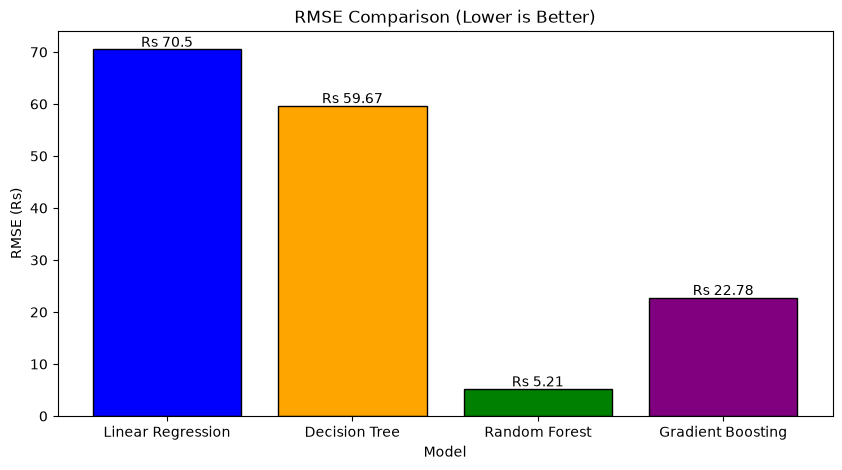

In [30]:
# Bar chart - RMSE comparison
models = comparison_df['Model']
rmse_vals = comparison_df['RMSE']

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_vals, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('RMSE Comparison (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('RMSE (Rs)')
for i in range(len(models)):
    plt.text(i, rmse_vals.values[i] + 0.5, 'Rs ' + str(rmse_vals.values[i]),
             ha='center', fontsize=10)
plt.show()

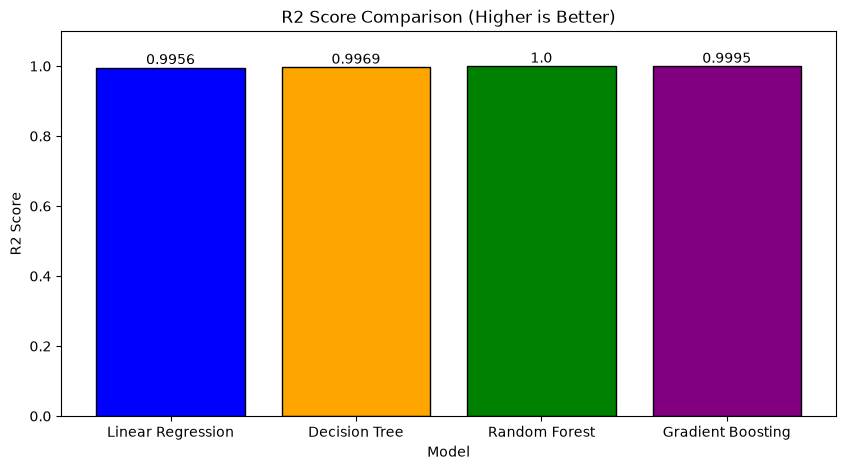

In [31]:
# Bar chart - R2 Score comparison
r2_vals = comparison_df['R2 Score']

plt.figure(figsize=(10, 5))
plt.bar(models, r2_vals, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('R2 Score Comparison (Higher is Better)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
for i in range(len(models)):
    plt.text(i, r2_vals.values[i] + 0.01, str(r2_vals.values[i]),
             ha='center', fontsize=10)
plt.show()

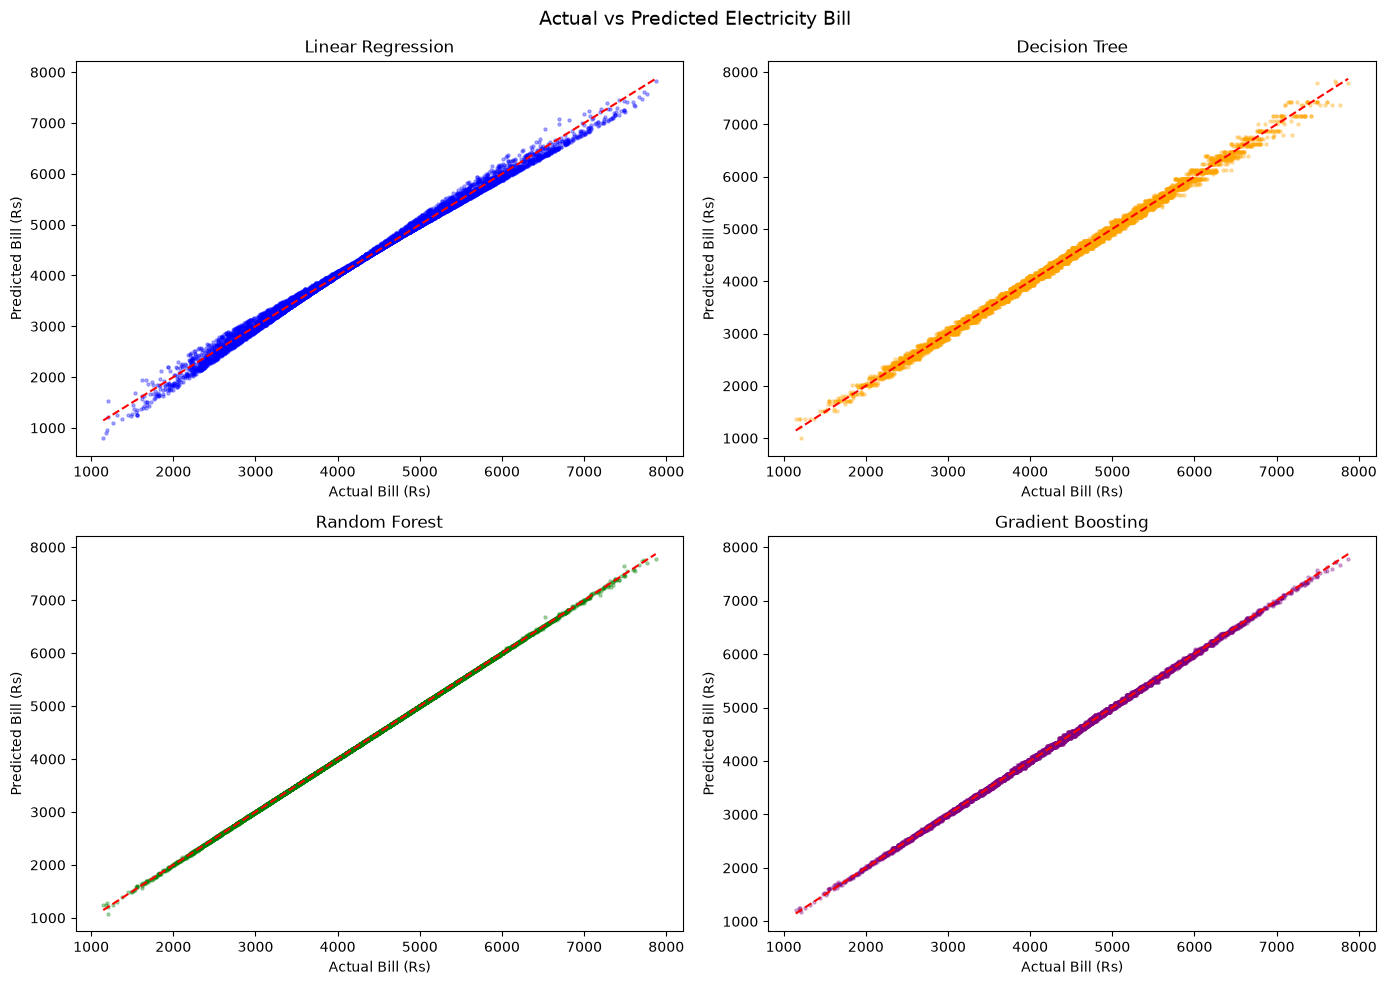

In [32]:
# Actual vs Predicted plots for all 4 models

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].scatter(y_test, y_pred_lr, alpha=0.3, s=5, color='blue')
axes[0][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][0].set_title('Linear Regression')
axes[0][0].set_xlabel('Actual Bill (Rs)')
axes[0][0].set_ylabel('Predicted Bill (Rs)')

axes[0][1].scatter(y_test, y_pred_dt, alpha=0.3, s=5, color='orange')
axes[0][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][1].set_title('Decision Tree')
axes[0][1].set_xlabel('Actual Bill (Rs)')
axes[0][1].set_ylabel('Predicted Bill (Rs)')

axes[1][0].scatter(y_test, y_pred_rf, alpha=0.3, s=5, color='green')
axes[1][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][0].set_title('Random Forest')
axes[1][0].set_xlabel('Actual Bill (Rs)')
axes[1][0].set_ylabel('Predicted Bill (Rs)')

axes[1][1].scatter(y_test, y_pred_gb, alpha=0.3, s=5, color='purple')
axes[1][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][1].set_title('Gradient Boosting')
axes[1][1].set_xlabel('Actual Bill (Rs)')
axes[1][1].set_ylabel('Predicted Bill (Rs)')

plt.suptitle('Actual vs Predicted Electricity Bill', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 10 - Best Model and Feature Importance

In [33]:
# Find the best model based on highest R2 Score
best_index = comparison_df['R2 Score'].idxmax()
best_row   = comparison_df.loc[best_index]

print("Best Model :", best_row['Model'])
print("MAE        :", best_row['MAE'], "Rs")
print("RMSE       :", best_row['RMSE'], "Rs")
print("R2 Score   :", best_row['R2 Score'])
print()
print("Why this model is best:")
print("It has the highest R2 Score, which means it explains the most variation in electricity bills.")
print("It also has the lowest RMSE, meaning its predictions are closest to the actual values.")

Best Model : Random Forest
MAE        : 1.41 Rs
RMSE       : 5.21 Rs
R2 Score   : 1.0

Why this model is best:
It has the highest R2 Score, which means it explains the most variation in electricity bills.
It also has the lowest RMSE, meaning its predictions are closest to the actual values.


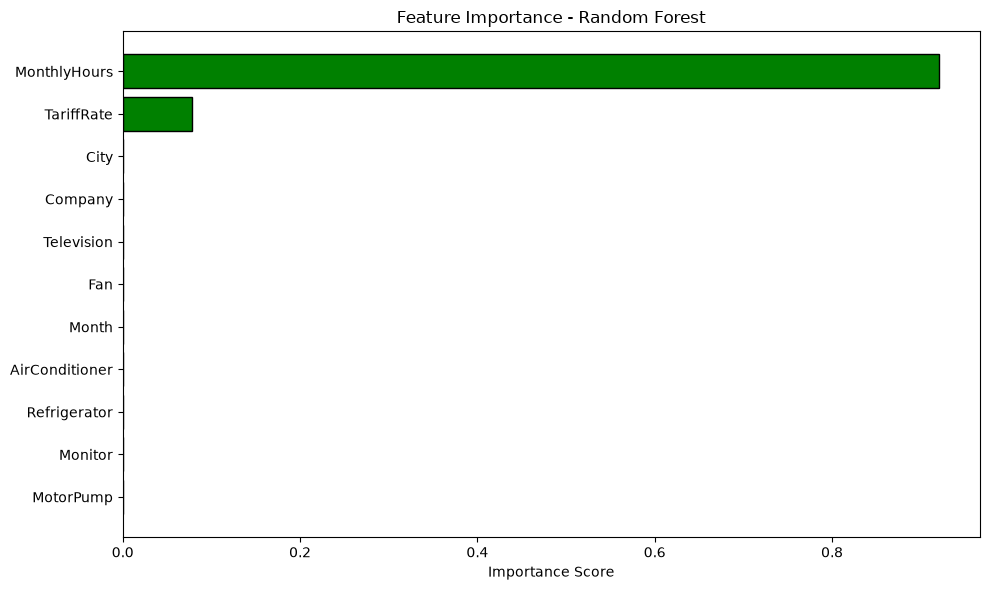

Insight: The most important features for predicting electricity bill are:
 - MonthlyHours ( 92.1 % importance)
 - TariffRate ( 7.8 % importance)
 - City ( 0.1 % importance)


In [34]:
# Feature Importance from Random Forest
# Which features have the most impact on the electricity bill?

feature_names = X_train.columns
importances   = model_rf.feature_importances_

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='green', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Insight: The most important features for predicting electricity bill are:")
top3 = imp_df.sort_values('Importance', ascending=False).head(3)
for i, row in top3.iterrows():
    print(" -", row['Feature'], "(", round(row['Importance']*100, 1), "% importance)")

---
## Step 11 - Predict Bill for a New House

In [35]:
# Let's predict the electricity bill for a sample household
# A house in Mumbai with 2 ACs, summer month (May)

# City encoding - check what number Mumbai got
city_list   = list(le_city.classes_)
mumbai_code = le_city.transform(['Mumbai'])[0]
print("Mumbai city code:", mumbai_code)

company_list  = list(le_company.classes_)
# Use first company code as example
company_code  = 0

new_house = pd.DataFrame({
    'Fan'            : [3],
    'Refrigerator'   : [1],
    'AirConditioner' : [2],
    'Television'     : [2],
    'Monitor'        : [1],
    'MotorPump'      : [0],
    'Month'          : [5],
    'City'           : [mumbai_code],
    'Company'        : [company_code],
    'MonthlyHours'   : [450],
    'TariffRate'     : [8.5]
})

# Make sure columns are in same order as training data
new_house = new_house[X_train.columns]

# Use Random Forest for prediction (it was our best model)
predicted_bill = model_rf.predict(new_house)[0]

print()
print("House Details:")
print("  City            : Mumbai")
print("  Month           : May (Summer)")
print("  Fans            : 3")
print("  Air Conditioners: 2")
print("  Monthly Hours   : 450")
print("  Tariff Rate     : Rs 8.5 per unit")
print()
print("Predicted Electricity Bill: Rs", round(predicted_bill, 2))

Mumbai city code: 7

House Details:
  City            : Mumbai
  Month           : May (Summer)
  Fans            : 3
  Air Conditioners: 2
  Monthly Hours   : 450
  Tariff Rate     : Rs 8.5 per unit

Predicted Electricity Bill: Rs 3815.19


---
## Conclusion

In this project we built a Machine Learning model to predict the monthly electricity bill of a household based on appliance usage and other factors.

**What we did:**
1. Loaded the dataset with 45,345 rows and 12 columns
2. Checked for missing values and duplicates
3. Encoded categorical columns (City and Company)
4. Created 7 visualizations to understand the data
5. Split data into 80% training and 20% testing
6. Trained 4 regression models
7. Compared all models and selected the best one
8. Predicted electricity bill for a new household

**Key Findings:**
- Monthly Hours of usage and Tariff Rate are the most important factors for electricity bill
- Air Conditioner usage significantly increases the electricity bill
- Bills are higher in summer months (April to June) due to AC usage
- Random Forest and Gradient Boosting performed much better than Linear Regression

**Limitations:**
- Dataset does not include house size or number of rooms
- Exact hours of usage per appliance is not captured separately
- Does not include seasonal weather data

**Future Improvements:**
- Add features like house size, number of rooms, number of people in house
- Include actual hours used per appliance
- Build a simple web app where people can enter their appliance details and get a bill prediction
- Try hyperparameter tuning to further improve model accuracy

---

## References
1. Kaggle - Household Electricity Bill Dataset: https://www.kaggle.com
2. Scikit-learn Documentation: https://scikit-learn.org
3. Ministry of Power, Government of India - Electricity Tariff Rates: https://powermin.gov.in